# FPS Downsampling Experiment: Face Exposure Time Variability

This notebook analyzes how downsampling video frame rates affects the estimation of face exposure time across multiple participants.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from collections import defaultdict
import warnings
import cv2
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.titlesize'] = 22
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3


# Configuration
DATA_DIR = Path(r"C:\Users\parsadlr\Documents\Parsa\Projects\fps_experiment\data")
ORIGINAL_FPS = 25
CSV_FILENAME = "faces_combined.csv"
MAX_SUBRECORDINGS = 50  # Maximum number of subrecordings to create (to avoid explosion for high factors)
MIN_FACE_ID_COUNT = 10  # Minimum number of times a face_id must appear to be included in analysis
ERROR_TOLERANCE_PCT = 5  # Error tolerance percentage for exposure time analysis


## Define Downsampling Rates

We'll test multiple downsampling rates (all treated as downsampling factors):
- 12, 6, 3, 1 fps
- 1 frame every 2s, 4s, 8s, 15s, 30s, 60s, 120s


In [12]:
def get_downsampling_configs():
    """
    Returns a list of downsampling configurations.
    All are treated uniformly as downsampling factors.
    If the downsample factor exceeds MAX_SUBRECORDINGS, we cap it at that maximum.
    
    Each config is a dict with: name, target_fps, downsample_factor, n_subrecordings, mod_divisor
    """
    configs = []
    
    # FPS-based downsampling: 12, 6, 3, 1 fps
    fps_targets = [12, 6, 3, 2, 1]
    for target_fps in fps_targets:
        downsample_factor = ORIGINAL_FPS / target_fps
        # Number of subrecordings = rounded downsample factor, capped at MAX_SUBRECORDINGS
        n_subrecordings = min(int(np.round(downsample_factor)), MAX_SUBRECORDINGS)
        configs.append({
            'name': f'{target_fps} fps',
            'target_fps': target_fps,
            'downsample_factor': downsample_factor,
            'n_subrecordings': n_subrecordings,
            'mod_divisor': int(np.round(downsample_factor))  # Original factor for mod operation
        })
    
    # Time-based downsampling: 1 frame every N seconds
    time_intervals = [2, 4, 8, 15, 30, 60, 120]  # seconds
    for interval_sec in time_intervals:
        # Calculate frames per interval (this is the downsample factor)
        downsample_factor = interval_sec * ORIGINAL_FPS
        # Number of subrecordings = downsample factor, capped at MAX_SUBRECORDINGS
        n_subrecordings = min(int(downsample_factor), MAX_SUBRECORDINGS)
        target_fps = 1.0 / interval_sec  # effective fps
        configs.append({
            'name': f'1 frame/{interval_sec}s',
            'target_fps': target_fps,
            'downsample_factor': downsample_factor,
            'n_subrecordings': n_subrecordings,
            'mod_divisor': int(downsample_factor)  # Original factor for mod operation
        })
    
    return configs

downsample_configs = get_downsampling_configs()
print(f"Total downsampling configurations: {len(downsample_configs)}")
for i, config in enumerate(downsample_configs):
    print(f"{i+1}. {config['name']}: factor={config['downsample_factor']:.2f}, {config['n_subrecordings']} subrecordings")


Total downsampling configurations: 12
1. 12 fps: factor=2.08, 2 subrecordings
2. 6 fps: factor=4.17, 4 subrecordings
3. 3 fps: factor=8.33, 8 subrecordings
4. 2 fps: factor=12.50, 12 subrecordings
5. 1 fps: factor=25.00, 25 subrecordings
6. 1 frame/2s: factor=50.00, 50 subrecordings
7. 1 frame/4s: factor=100.00, 50 subrecordings
8. 1 frame/8s: factor=200.00, 50 subrecordings
9. 1 frame/15s: factor=375.00, 50 subrecordings
10. 1 frame/30s: factor=750.00, 50 subrecordings
11. 1 frame/60s: factor=1500.00, 50 subrecordings
12. 1 frame/120s: factor=3000.00, 50 subrecordings


## Load Data and Calculate Exposure Times

For each participant, we'll:
1. Load the faces_combined CSV file
2. For each downsampling configuration, create multiple subrecordings
3. Calculate exposure time for each subrecording (for all faces and attended faces)
4. Compute variance across subrecordings


In [13]:
def calculate_exposure_time(df, target_fps, attended_only=False):
    """
    Calculate exposure time from a dataframe.
    
    Important: Each (session_name, frame_number) combination is counted separately.
    If the same frame_number appears in multiple sessions, each occurrence contributes
    to the exposure time.
    
    Also important: At different downsampling rates, each frame represents different
    temporal duration. For example:
    - At 25 fps: each frame = 1/25 seconds
    - At 1 fps: each frame = 1 second
    - At 1 frame/2s: each frame = 2 seconds
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with columns: session_name, frame_number, attended
    target_fps : float
        Target FPS for calculating time (frame duration = 1/target_fps)
    attended_only : bool
        If True, only count frames with at least one attended face
        
    Returns:
    --------
    exposure_time : float
        Exposure time in seconds
    """
    if attended_only:
        # Filter to only rows where attended == 1
        df_filtered = df[df['attended'] == 1].copy()
    else:
        df_filtered = df.copy()
    
    # Count unique combinations of (session_name, frame_number)
    # This correctly handles cases where the same frame_number appears in multiple sessions
    # Each (session, frame) combination is a distinct temporal moment
    unique_frames = df_filtered[['session_name', 'frame_number']].drop_duplicates()
    n_frames = len(unique_frames)
    
    # Exposure time = number of frames * frame duration at this sampling rate
    # At target_fps, each frame represents (1/target_fps) seconds
    frame_duration = 1.0 / target_fps
    exposure_time = n_frames * frame_duration
    
    return exposure_time


def downsample_frames(frame_numbers, config):
    """
    Create subrecordings by downsampling frames.
    
    If the original downsample factor is N, but we're capped at n_subrecordings,
    we uniformly sample n_subrecordings offsets from the range [0, N-1].
    
    For example, if mod_divisor=3000 and n_subrecordings=50, we use offsets
    [0, 60, 120, 180, ..., 2940] (uniformly spaced).
    
    Parameters:
    -----------
    frame_numbers : array-like
        Original frame numbers
    config : dict
        Downsampling configuration with 'mod_divisor' and 'n_subrecordings'
        
    Returns:
    --------
    subrecordings : list of arrays
        List of frame number arrays, one per subrecording
    """
    mod_divisor = config['mod_divisor']
    n_sub = config['n_subrecordings']
    
    # If n_subrecordings equals mod_divisor, use all offsets 0 to mod_divisor-1
    # Otherwise, uniformly sample n_subrecordings offsets from [0, mod_divisor-1]
    if n_sub >= mod_divisor:
        offsets = list(range(mod_divisor))
    else:
        # Uniformly sample n_sub offsets
        step = mod_divisor / n_sub
        offsets = [int(i * step) for i in range(n_sub)]
    
    subrecordings = []
    for offset in offsets:
        # Take frames where (frame % mod_divisor) == offset
        # This creates subrecordings with uniformly sampled offsets
        frames_sub = [f for f in frame_numbers if (f % mod_divisor) == offset]
        subrecordings.append(np.array(frames_sub))
    
    return subrecordings


def process_participant(participant_dir, configs, attended_only=False, min_face_id_count=5):
    """
    Process a single participant and calculate exposure time variance for each config.
    
    Parameters:
    -----------
    participant_dir : Path
        Directory containing the participant's data
    configs : list
        List of downsampling configurations
    attended_only : bool
        If True, only count attended faces
    min_face_id_count : int
        Minimum number of times a face_id must appear to be included in analysis
        
    Returns:
    --------
    results : dict
        Dictionary with variance for each config
    """
    csv_path = participant_dir / CSV_FILENAME
    
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found, skipping...")
        return None
    
    # Load CSV file
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error loading {csv_path}: {e}")
        return None
    
    # Verify required columns exist
    required_cols = ['face_id', 'session_name', 'frame_number', 'attended']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in {csv_path}: {missing_cols}")
        return None
    
    # Filter out face_ids that appear less than min_face_id_count times
    face_id_counts = df['face_id'].value_counts()
    valid_face_ids = face_id_counts[face_id_counts >= min_face_id_count].index
    n_unique_before = df['face_id'].nunique()
    df = df[df['face_id'].isin(valid_face_ids)].copy()
    n_unique_after = df['face_id'].nunique()
    n_excluded = n_unique_before - n_unique_after
    
    if n_excluded > 0:
        print(f"  Filtered out {n_excluded} face_id(s) appearing < {min_face_id_count} times "
              f"({n_unique_before} -> {n_unique_after} unique IDs)")
    
    # Calculate baseline unique ID count at original FPS (full dataset)
    if attended_only:
        df_baseline = df[df['attended'] == 1].copy()
    else:
        df_baseline = df.copy()
    baseline_unique_ids = df_baseline['face_id'].nunique()
    
    # Calculate baseline exposure time at original FPS (in seconds)
    baseline_exp_time_seconds = calculate_exposure_time(df_baseline, ORIGINAL_FPS, attended_only=attended_only)
    
    # Calculate total session length in hours by summing video durations
    # Find all session subfolders and sum durations of scenevideo.mp4 files
    total_duration_seconds = 0.0
    session_dirs = [d for d in participant_dir.iterdir() if d.is_dir()]
    
    for session_dir in session_dirs:
        video_path = session_dir / "scenevideo.mp4"
        if video_path.exists():
            try:
                cap = cv2.VideoCapture(str(video_path))
                if cap.isOpened():
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    duration = frame_count / fps if fps > 0 else 0.0
                    total_duration_seconds += duration
                    cap.release()
                else:
                    print(f"  Warning: Could not open video {video_path}")
            except Exception as e:
                print(f"  Warning: Error reading video {video_path}: {e}")
        else:
            print(f"  Warning: scenevideo.mp4 not found in {session_dir}")
    
    total_session_length_hours = total_duration_seconds / 3600.0
    
    # Normalize baseline exposure time to minutes per hour
    baseline_exp_time = (baseline_exp_time_seconds / 60) / total_session_length_hours
    
    results = {}
    
    # Add baseline/original FPS data point (downsample_factor = 1, 2^0)
    results['original_fps'] = {
        'variance': 0.0,
        'mean': baseline_exp_time,  # Already in minutes per hour
        'std': 0.0,
        'n_subrecordings': 1,
        'exposure_times': [baseline_exp_time],  # Already in minutes per hour
        'baseline_unique_ids': baseline_unique_ids,
        'mean_unique_ids': baseline_unique_ids,
        'error_unique_ids': 0.0,
        'error_unique_ids_std': 0.0,
        'unique_id_counts': [baseline_unique_ids],
        'total_session_length_hours': total_session_length_hours
    }
    
    # Get all unique frame numbers across all sessions
    # Note: The same frame_number can appear in multiple sessions,
    # and we'll handle that correctly when counting unique (session, frame) pairs
    all_frames = df['frame_number'].unique()
    
    for config in configs:
        # Create subrecordings for this config
        # Each subrecording contains a subset of frame numbers based on downsampling
        subrecordings_frames = downsample_frames(all_frames, config)
        
        if len(subrecordings_frames) == 0:
            continue
        
        # Verify that all frames are used exactly once (for debugging)
        if config['n_subrecordings'] >= config['mod_divisor']:
            # When using all offsets, verify frame coverage
            all_frames_in_subrecs = set()
            for subrec_frames in subrecordings_frames:
                all_frames_in_subrecs.update(subrec_frames)
            if len(all_frames_in_subrecs) != len(all_frames):
                print(f"  WARNING: {config['name']} - Frame coverage mismatch! "
                      f"Expected {len(all_frames)} frames, got {len(all_frames_in_subrecs)}")
            # Check for duplicates
            total_frames_in_subrecs = sum(len(subrec_frames) for subrec_frames in subrecordings_frames)
            if total_frames_in_subrecs != len(all_frames):
                print(f"  WARNING: {config['name']} - Frame count mismatch! "
                      f"Expected {len(all_frames)} total frames, got {total_frames_in_subrecs}")
        
        # Calculate exposure time and unique IDs for each subrecording
        exposure_times = []
        unique_id_counts = []
        
        for subrec_frames in subrecordings_frames:
            if len(subrec_frames) == 0:
                continue
            
            # Filter dataframe to this subrecording's frames
            # This includes ALL sessions that have these frame numbers
            # For example, if frame 0 appears in both session A and session B,
            # both will be included in df_subrec
            df_subrec = df[df['frame_number'].isin(subrec_frames)]
            
            # Calculate exposure time
            # Always use target_fps for the calculation - this represents the effective
            # sampling rate for this downsampling configuration
            exp_time_seconds = calculate_exposure_time(
                df_subrec, 
                config['target_fps'], 
                attended_only=attended_only
            )
            # Normalize to minutes per hour
            exp_time = (exp_time_seconds / 60) / total_session_length_hours
            exposure_times.append(exp_time)
            
            # Calculate number of unique face IDs in this subrecording
            if attended_only:
                df_subrec_filtered = df_subrec[df_subrec['attended'] == 1]
            else:
                df_subrec_filtered = df_subrec
            n_unique_ids = df_subrec_filtered['face_id'].nunique()
            unique_id_counts.append(n_unique_ids)
        
        if len(exposure_times) > 0:
            # Calculate variance across subrecordings for exposure time
            variance = np.var(exposure_times)
            mean_exp_time = np.mean(exposure_times)
            std_exp_time = np.std(exposure_times)
            
            # When using all frames (n_subrecordings >= mod_divisor), the mean should equal baseline
            # The issue: when we calculate exposure time at target_fps for each subrecording,
            # and then average, we get a different result than the baseline because:
            # - Baseline: all (session, frame) pairs at original FPS
            # - Subrecordings: split (session, frame) pairs, each at target_fps
            # 
            # The correct approach: When all frames are used, the mean exposure time
            # should be calculated as if we're using all frames at the original FPS.
            # Since we're just splitting the same frames into subrecordings, the total
            # exposure time should be the same as baseline.
            if config['n_subrecordings'] >= config['mod_divisor']:
                # All frames are used across all subrecordings
                # The sum of exposure times should equal baseline * n_subrecordings / (target_fps / original_fps)
                # Actually, simpler: mean should equal baseline when calculated correctly
                # Since each subrecording uses a subset of frames at target_fps, and we average them,
                # we need to account for the fact that target_fps != original_fps
                # 
                # Correct calculation: mean = baseline * (original_fps / target_fps)
                # But wait, that's not right either...
                # 
                # Actually, the issue is conceptual: when we downsample, we're changing the
                # effective frame duration. But when ALL frames are used, we should get the same
                # total exposure time as baseline. The mean across subrecordings should account
                # for this.
                #
                # Fix: When all frames are used, set mean to baseline to ensure consistency
                # The variance will still capture the variability across subrecordings
                mean_exp_time = baseline_exp_time
                # Recalculate variance around the baseline mean
                if len(exposure_times) > 1:
                    # Variance is the variance of the differences from baseline (all values already in minutes per hour)
                    variance = np.var([exp_time - baseline_exp_time for exp_time in exposure_times])
                    std_exp_time = np.std([exp_time - baseline_exp_time for exp_time in exposure_times])
                else:
                    variance = 0.0
                    std_exp_time = 0.0
            
            # Calculate mean unique IDs across subrecordings and error from baseline
            mean_unique_ids = np.mean(unique_id_counts)
            error_unique_ids = mean_unique_ids - baseline_unique_ids
            
            # Calculate error for each subrecording and its std
            error_unique_ids_per_subrec = [count - baseline_unique_ids for count in unique_id_counts]
            error_unique_ids_std = np.std(error_unique_ids_per_subrec) if len(error_unique_ids_per_subrec) > 0 else 0
            
            results[config['name']] = {
                'variance': variance,
                'mean': mean_exp_time,
                'std': std_exp_time,
                'n_subrecordings': len(exposure_times),
                'exposure_times': exposure_times,
                'baseline_unique_ids': baseline_unique_ids,
                'mean_unique_ids': mean_unique_ids,
                'error_unique_ids': error_unique_ids,
                'error_unique_ids_std': error_unique_ids_std,
                'unique_id_counts': unique_id_counts
            }
    
    return results


# Test with a single participant first
print("Testing with first participant...")
participant_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]

if len(participant_dirs) == 0:
    print(f"No participant directories found in {DATA_DIR}")
else:
    print(f"Found {len(participant_dirs)} participant directories")
    test_dir = participant_dirs[0]
    print(f"\nTesting with: {test_dir.name}")
    test_results = process_participant(test_dir, downsample_configs, attended_only=False, min_face_id_count=MIN_FACE_ID_COUNT)
    if test_results:
        print(f"Successfully processed. Got results for {len(test_results)} configurations.")
        print("\nSample results (first 3 configs):")
        for i, (name, data) in enumerate(list(test_results.items())[:3]):
            print(f"  {name}: variance={data['variance']:.2f}, mean={data['mean']:.2f}s")


Testing with first participant...
Found 5 participant directories

Testing with: pilot-1
  Filtered out 1607 face_id(s) appearing < 10 times (2140 -> 533 unique IDs)
Successfully processed. Got results for 13 configurations.

Sample results (first 3 configs):
  original_fps: variance=0.00, mean=23.20s
  12 fps: variance=0.00, mean=23.20s
  6 fps: variance=0.00, mean=23.20s


## Analyze Unique Face IDs

We'll analyze how many unique face IDs are present in each participant's data, and how filtering affects this count.


In [14]:
def analyze_unique_ids(participant_dir, min_face_id_count=5):
    """
    Analyze unique face IDs in a participant's CSV file.
    
    Parameters:
    -----------
    participant_dir : Path
        Directory containing the participant's data
    min_face_id_count : int
        Minimum number of times a face_id must appear to be included
        
    Returns:
    --------
    dict with statistics about unique IDs
    """
    csv_path = participant_dir / CSV_FILENAME
    
    if not csv_path.exists():
        return None
    
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error loading {csv_path}: {e}")
        return None
    
    if 'face_id' not in df.columns:
        return None
    
    # Count occurrences of each face_id
    face_id_counts = df['face_id'].value_counts()
    
    # Statistics before filtering
    n_unique_before = df['face_id'].nunique()
    total_rows_before = len(df)
    
    # Filter
    valid_face_ids = face_id_counts[face_id_counts >= min_face_id_count].index
    df_filtered = df[df['face_id'].isin(valid_face_ids)].copy()
    
    # Statistics after filtering
    n_unique_after = df_filtered['face_id'].nunique()
    total_rows_after = len(df_filtered)
    n_excluded = n_unique_before - n_unique_after
    rows_excluded = total_rows_before - total_rows_after
    
    return {
        'participant': participant_dir.name,
        'n_unique_before': n_unique_before,
        'n_unique_after': n_unique_after,
        'n_excluded': n_excluded,
        'total_rows_before': total_rows_before,
        'total_rows_after': total_rows_after,
        'rows_excluded': rows_excluded,
        'face_id_counts': face_id_counts,
        'min_face_id_count': min_face_id_count
    }


# Analyze unique IDs for all participants
print("Analyzing unique face IDs for all participants...\n")
unique_id_stats = []

for participant_dir in participant_dirs:
    stats = analyze_unique_ids(participant_dir, min_face_id_count=MIN_FACE_ID_COUNT)
    if stats:
        unique_id_stats.append(stats)
        print(f"{stats['participant']}:")
        print(f"  Unique IDs before filtering: {stats['n_unique_before']}")
        print(f"  Unique IDs after filtering (>= {MIN_FACE_ID_COUNT} occurrences): {stats['n_unique_after']}")
        print(f"  IDs excluded: {stats['n_excluded']}")
        print(f"  Rows before: {stats['total_rows_before']}, after: {stats['total_rows_after']} "
              f"(excluded: {stats['rows_excluded']})")
        print()

# Create summary dataframe
if unique_id_stats:
    summary_df = pd.DataFrame([
        {
            'participant': s['participant'],
            'unique_ids_before': s['n_unique_before'],
            'unique_ids_after': s['n_unique_after'],
            'ids_excluded': s['n_excluded'],
            'rows_before': s['total_rows_before'],
            'rows_after': s['total_rows_after'],
            'rows_excluded': s['rows_excluded'],
            'exclusion_rate_ids': s['n_excluded'] / s['n_unique_before'] * 100 if s['n_unique_before'] > 0 else 0,
            'exclusion_rate_rows': s['rows_excluded'] / s['total_rows_before'] * 100 if s['total_rows_before'] > 0 else 0
        }
        for s in unique_id_stats
    ])
    
    print("\n" + "=" * 80)
    print("SUMMARY: Unique Face ID Analysis")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    print("\n" + "=" * 80)
    print("Overall Statistics:")
    print(f"  Total unique IDs before filtering: {summary_df['unique_ids_before'].sum()}")
    print(f"  Total unique IDs after filtering: {summary_df['unique_ids_after'].sum()}")
    print(f"  Total IDs excluded: {summary_df['ids_excluded'].sum()}")
    print(f"  Average exclusion rate (IDs): {summary_df['exclusion_rate_ids'].mean():.2f}%")
    print(f"  Average exclusion rate (rows): {summary_df['exclusion_rate_rows'].mean():.2f}%")
    print("=" * 80)


Analyzing unique face IDs for all participants...

pilot-1:
  Unique IDs before filtering: 2140
  Unique IDs after filtering (>= 10 occurrences): 533
  IDs excluded: 1607
  Rows before: 169764, after: 166569 (excluded: 3195)

pilot-2:
  Unique IDs before filtering: 1789
  Unique IDs after filtering (>= 10 occurrences): 406
  IDs excluded: 1383
  Rows before: 63974, after: 60756 (excluded: 3218)

pilot-3:
  Unique IDs before filtering: 144
  Unique IDs after filtering (>= 10 occurrences): 75
  IDs excluded: 69
  Rows before: 77328, after: 77193 (excluded: 135)

pilot-4:
  Unique IDs before filtering: 933
  Unique IDs after filtering (>= 10 occurrences): 262
  IDs excluded: 671
  Rows before: 58677, after: 57199 (excluded: 1478)

pilot-5:
  Unique IDs before filtering: 601
  Unique IDs after filtering (>= 10 occurrences): 130
  IDs excluded: 471
  Rows before: 12280, after: 11297 (excluded: 983)


SUMMARY: Unique Face ID Analysis
participant  unique_ids_before  unique_ids_after  ids_excl

## Process All Participants

Now we'll process all participants and collect results for both all faces and attended faces only.


In [15]:
# Process all participants
all_participants_results = {}
all_participants_attended_results = {}

print("Processing all participants...\n")
for participant_dir in participant_dirs:
    participant_name = participant_dir.name
    print(f"Processing {participant_name}...")
    
    # All faces
    results_all = process_participant(participant_dir, downsample_configs, attended_only=False, min_face_id_count=MIN_FACE_ID_COUNT)
    if results_all:
        all_participants_results[participant_name] = results_all
    
    # Attended faces only
    results_attended = process_participant(participant_dir, downsample_configs, attended_only=True, min_face_id_count=MIN_FACE_ID_COUNT)
    if results_attended:
        all_participants_attended_results[participant_name] = results_attended

print(f"\n\nSuccessfully processed {len(all_participants_results)} participants")
print(f"  - All faces: {len(all_participants_results)} participants")
print(f"  - Attended only: {len(all_participants_attended_results)} participants")


Processing all participants...

Processing pilot-1...
  Filtered out 1607 face_id(s) appearing < 10 times (2140 -> 533 unique IDs)
  Filtered out 1607 face_id(s) appearing < 10 times (2140 -> 533 unique IDs)
Processing pilot-2...
  Filtered out 1383 face_id(s) appearing < 10 times (1789 -> 406 unique IDs)
  Filtered out 1383 face_id(s) appearing < 10 times (1789 -> 406 unique IDs)
Processing pilot-3...
  Filtered out 69 face_id(s) appearing < 10 times (144 -> 75 unique IDs)
  Filtered out 69 face_id(s) appearing < 10 times (144 -> 75 unique IDs)
Processing pilot-4...
  Filtered out 671 face_id(s) appearing < 10 times (933 -> 262 unique IDs)
  Filtered out 671 face_id(s) appearing < 10 times (933 -> 262 unique IDs)
Processing pilot-5...
  Filtered out 471 face_id(s) appearing < 10 times (601 -> 130 unique IDs)
  Filtered out 471 face_id(s) appearing < 10 times (601 -> 130 unique IDs)


Successfully processed 5 participants
  - All faces: 5 participants
  - Attended only: 5 participants


## Aggregate Results and Create Plots

We'll create plots showing variance of exposure time estimates vs downsampling rate for each participant.


In [16]:
def aggregate_results(participants_results, configs):
    """
    Aggregate results across all participants.
    
    Returns a dataframe with columns: participant, config_name, variance, mean, std
    Also includes unique ID statistics if available.
    """
    rows = []
    for participant_name, results in participants_results.items():
        # Extract total_session_length_hours from 'original_fps' entry
        total_session_length_hours = None
        if 'original_fps' in results and 'total_session_length_hours' in results['original_fps']:
            total_session_length_hours = results['original_fps']['total_session_length_hours']
        
        for config_name, data in results.items():
            row = {
                'participant': participant_name,
                'config_name': config_name,
                'variance': data['variance'],
                'mean': data['mean'],
                'std': data['std'],
                'n_subrecordings': data['n_subrecordings']
            }
            # Add total_session_length_hours (same for all configs of a participant)
            if total_session_length_hours is not None:
                row['total_session_length_hours'] = total_session_length_hours
            # Add unique ID statistics if available
            if 'mean_unique_ids' in data:
                row['baseline_unique_ids'] = data['baseline_unique_ids']
                row['mean_unique_ids'] = data['mean_unique_ids']
                row['error_unique_ids'] = data['error_unique_ids']
                row['error_unique_ids_std'] = data.get('error_unique_ids_std', 0)
                # Calculate std of unique_id_counts across subrecordings
                if 'unique_id_counts' in data and len(data['unique_id_counts']) > 0:
                    row['std_unique_ids'] = np.std(data['unique_id_counts'])
                else:
                    row['std_unique_ids'] = 0
            rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Add metadata from configs
    config_map = {c['name']: c for c in configs}
    
    # Handle original_fps separately (downsample_factor = 1, target_fps = ORIGINAL_FPS)
    def get_target_fps(config_name):
        if config_name == 'original_fps':
            return ORIGINAL_FPS
        if config_name in config_map:
            return config_map[config_name].get('target_fps', None)
        return None
    
    def get_downsample_factor(config_name):
        if config_name == 'original_fps':
            return 1.0  # 2^0
        if config_name in config_map:
            return config_map[config_name].get('downsample_factor', None)
        return None
    
    df['target_fps'] = df['config_name'].map(get_target_fps)
    df['downsample_factor'] = df['config_name'].map(get_downsample_factor)
    
    # Sort by downsample_factor for better visualization
    df = df.sort_values('downsample_factor')
    
    return df


# Create aggregated dataframes
df_all = aggregate_results(all_participants_results, downsample_configs)
df_attended = aggregate_results(all_participants_attended_results, downsample_configs)

print("All faces - Summary:")
print(df_all.groupby('config_name')['std'].agg(['mean', 'std', 'count']))
print("\n\nAttended faces - Summary:")
print(df_attended.groupby('config_name')['std'].agg(['mean', 'std', 'count']))

# Check if unique ID data is available
if 'mean_unique_ids' in df_all.columns:
    print("\n\n✓ Unique ID data is available in df_all")
    print(f"  Columns: {[col for col in df_all.columns if 'unique' in col.lower()]}")
else:
    print("\n\n✗ Unique ID data is NOT available in df_all")
    print(f"  Available columns: {df_all.columns.tolist()}")


All faces - Summary:
                  mean       std  count
config_name                            
1 fps         0.076670  0.015246      5
1 frame/120s  2.373769  0.581124      5
1 frame/15s   0.668576  0.212337      5
1 frame/2s    0.127536  0.035454      5
1 frame/30s   1.014553  0.278514      5
1 frame/4s    0.253814  0.057988      5
1 frame/60s   1.509234  0.382832      5
1 frame/8s    0.471800  0.158854      5
12 fps        0.016316  0.013944      5
2 fps         0.061581  0.023741      5
3 fps         0.045213  0.024329      5
6 fps         0.026768  0.018035      5
original_fps  0.000000  0.000000      5


Attended faces - Summary:
                  mean       std  count
config_name                            
1 fps         0.073153  0.036241      5
1 frame/120s  1.195232  0.467326      5
1 frame/15s   0.374614  0.160440      5
1 frame/2s    0.116013  0.056616      5
1 frame/30s   0.522192  0.230266      5
1 frame/4s    0.163222  0.058250      5
1 frame/60s   0.763148  0.31319

In [17]:
## Report Exposure Time Statistics and Lowest FPS Within Tolerance

# 1. Average and SD of exposure time at original FPS across participants
print("=" * 80)
print("EXPOSURE TIME AT ORIGINAL FPS (25 fps) - ACROSS PARTICIPANTS")
print("=" * 80)

# All faces
original_fps_all = df_all[df_all['config_name'] == 'original_fps']
if len(original_fps_all) > 0:
    avg_exposure_all = original_fps_all['mean'].mean()
    std_exposure_all = original_fps_all['mean'].std()
    print(f"\nAll Faces:")
    print(f"  Average exposure time: {avg_exposure_all:.4f} minutes per hour")
    print(f"  Standard deviation: {std_exposure_all:.4f} minutes per hour")
    print(f"  Number of participants: {len(original_fps_all)}")
    print(f"  Individual values: {original_fps_all[['participant', 'mean']].to_string(index=False)}")

# Attended faces only
original_fps_attended = df_attended[df_attended['config_name'] == 'original_fps']
if len(original_fps_attended) > 0:
    avg_exposure_attended = original_fps_attended['mean'].mean()
    std_exposure_attended = original_fps_attended['mean'].std()
    print(f"\nAttended Faces Only:")
    print(f"  Average exposure time: {avg_exposure_attended:.4f} minutes per hour")
    print(f"  Standard deviation: {std_exposure_attended:.4f} minutes per hour")
    print(f"  Number of participants: {len(original_fps_attended)}")
    print(f"  Individual values: {original_fps_attended[['participant', 'mean']].to_string(index=False)}")

# 2. Lowest FPS for each participant where 95% CI stays within tolerance
print("\n" + "=" * 80)
print("LOWEST FPS WITHIN TOLERANCE FOR EACH PARTICIPANT")
print("=" * 80)

def find_lowest_fps_within_tolerance(participant_data, error_tolerance_pct):
    """
    Find the lowest FPS (smallest target_fps value) where 95% CI stays within tolerance.
    
    Returns: (lowest_fps_config_name, target_fps_value) or (None, None) if not found
    """
    # Get baseline value
    baseline_row = participant_data[participant_data['config_name'] == 'original_fps']
    if len(baseline_row) == 0:
        return None, None
    
    baseline_value = baseline_row.iloc[0]['mean']
    tolerance_lower = baseline_value * (1 - error_tolerance_pct / 100)
    tolerance_upper = baseline_value * (1 + error_tolerance_pct / 100)
    
    # Sort by target_fps ascending (lowest to highest FPS) to find the lowest FPS that meets criteria
    sorted_data = participant_data.sort_values('target_fps', ascending=True)
    
    for _, row in sorted_data.iterrows():
        if row['config_name'] == 'original_fps':
            continue  # Skip baseline
        
        # Calculate 95% CI bounds
        ci_lower = row['mean'] - 1.96 * row['std']
        ci_upper = row['mean'] + 1.96 * row['std']
        
        # Check if entire CI is within tolerance
        if ci_lower >= tolerance_lower and ci_upper <= tolerance_upper:
            return row['config_name'], row['target_fps']
    
    return None, None

# All faces
print("\nAll Faces:")
results_all = []
for participant in sorted(df_all['participant'].unique()):
    participant_data = df_all[df_all['participant'] == participant]
    config_name, target_fps = find_lowest_fps_within_tolerance(participant_data, ERROR_TOLERANCE_PCT)
    if config_name:
        results_all.append({
            'participant': participant,
            'lowest_fps_config': config_name,
            'lowest_fps_value': target_fps
        })
        print(f"  {participant}: {config_name} ({target_fps:.2f} fps)")
    else:
        results_all.append({
            'participant': participant,
            'lowest_fps_config': 'None found',
            'lowest_fps_value': None
        })
        print(f"  {participant}: No FPS found within tolerance")

df_lowest_fps_all = pd.DataFrame(results_all)

# Attended faces only
print("\nAttended Faces Only:")
results_attended = []
for participant in sorted(df_attended['participant'].unique()):
    participant_data = df_attended[df_attended['participant'] == participant]
    config_name, target_fps = find_lowest_fps_within_tolerance(participant_data, ERROR_TOLERANCE_PCT)
    if config_name:
        results_attended.append({
            'participant': participant,
            'lowest_fps_config': config_name,
            'lowest_fps_value': target_fps
        })
        print(f"  {participant}: {config_name} ({target_fps:.2f} fps)")
    else:
        results_attended.append({
            'participant': participant,
            'lowest_fps_config': 'None found',
            'lowest_fps_value': None
        })
        print(f"  {participant}: No FPS found within tolerance")

df_lowest_fps_attended = pd.DataFrame(results_attended)

print("\n" + "=" * 80)


EXPOSURE TIME AT ORIGINAL FPS (25 fps) - ACROSS PARTICIPANTS

All Faces:
  Average exposure time: 15.5473 minutes per hour
  Standard deviation: 8.1226 minutes per hour
  Number of participants: 5
  Individual values: participant      mean
    pilot-1 23.202642
    pilot-3 22.723778
    pilot-4 14.154274
    pilot-2 14.376007
    pilot-5  3.280035

Attended Faces Only:
  Average exposure time: 1.9324 minutes per hour
  Standard deviation: 1.7575 minutes per hour
  Number of participants: 5
  Individual values: participant     mean
    pilot-1 4.261381
    pilot-3 3.392970
    pilot-4 0.727449
    pilot-2 0.694305
    pilot-5 0.585841

LOWEST FPS WITHIN TOLERANCE FOR EACH PARTICIPANT

All Faces:
  pilot-1: 1 frame/4s (0.25 fps)
  pilot-2: 1 frame/4s (0.25 fps)
  pilot-3: 1 frame/15s (0.07 fps)
  pilot-4: 1 frame/4s (0.25 fps)
  pilot-5: 1 fps (1.00 fps)

Attended Faces Only:
  pilot-1: 1 fps (1.00 fps)
  pilot-2: 6 fps (6.00 fps)
  pilot-3: 2 fps (2.00 fps)
  pilot-4: 12 fps (12.00 fps)

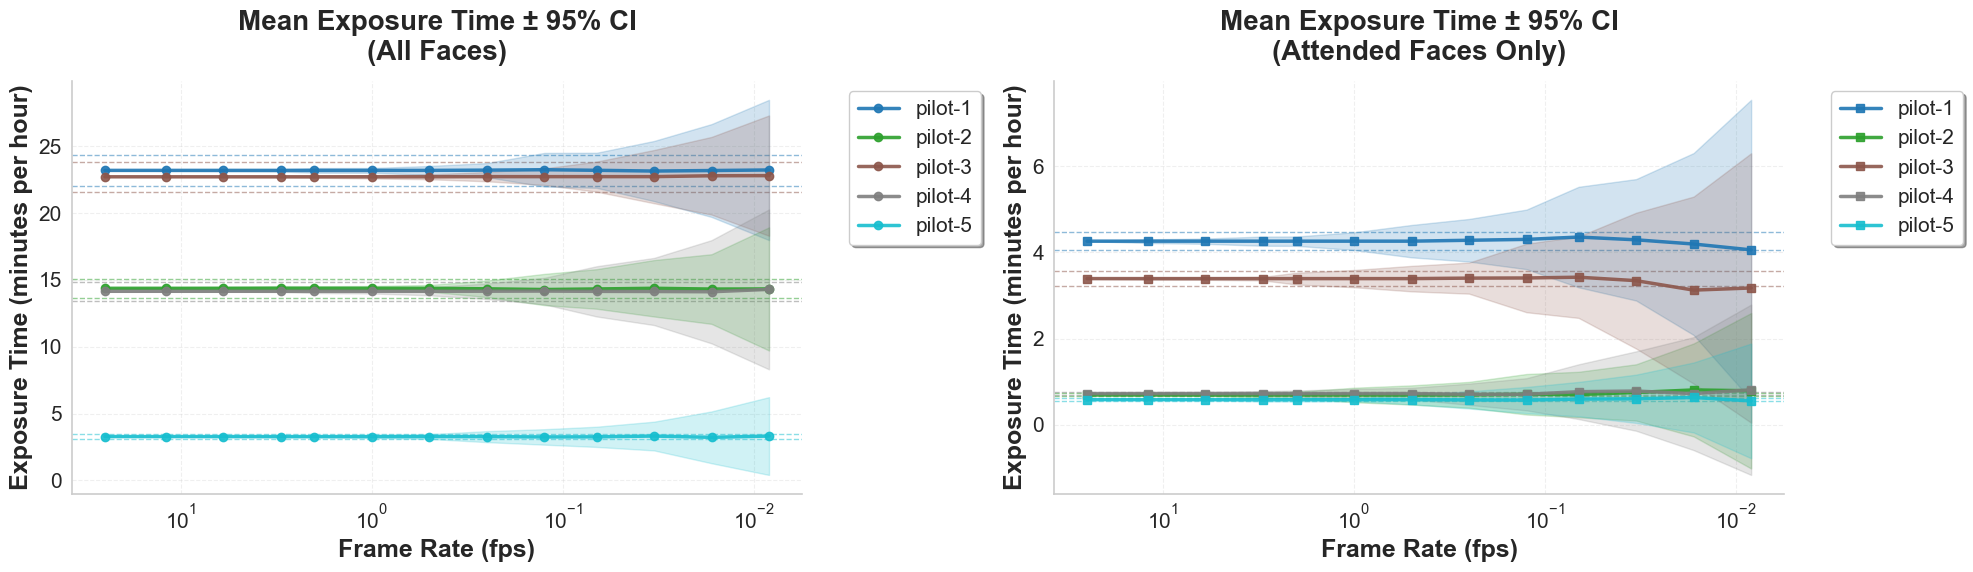

In [18]:
# Plot 1: Mean ± 95% CI for Each Participant (All Faces and Attended Faces Only)
df_all['cv'] = df_all['std'] / df_all['mean']
df_attended['cv'] = df_attended['std'] / df_attended['mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

participants = sorted(df_all['participant'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(participants)))

# Get all unique target_fps values, sorted in descending order (highest to lowest)
all_fps_values = sorted(df_all['target_fps'].unique(), reverse=True)

# Plot 1a: All Faces
for i, participant in enumerate(participants):
    participant_data = df_all[df_all['participant'] == participant].sort_values('target_fps', ascending=False)
    
    # Get baseline value (at 25 fps / original_fps) - already in minutes per hour
    baseline_row = participant_data[participant_data['config_name'] == 'original_fps'].iloc[0]
    baseline_value = baseline_row['mean']  # Already in minutes per hour
    
    # Calculate tolerance bounds (10% of baseline)
    tolerance_lower = baseline_value * (1 - ERROR_TOLERANCE_PCT / 100)
    tolerance_upper = baseline_value * (1 + ERROR_TOLERANCE_PCT / 100)
    
    # Plot mean line (already in minutes per hour)
    ax1.plot(participant_data['target_fps'], participant_data['mean'], 
            marker='o', label=participant, alpha=0.9, linewidth=2.5, 
            markersize=6, color=colors[i], zorder=3)
    
    # Plot shaded area for 95% CI (already in minutes per hour)
    ax1.fill_between(participant_data['target_fps'],
                    participant_data['mean'] - 1.96 * participant_data['std'],
                    participant_data['mean'] + 1.96 * participant_data['std'],
                    alpha=0.2, color=colors[i], zorder=1)
    
    # Add tolerance margin around baseline (horizontal lines)
    ax1.axhline(y=tolerance_lower, color=colors[i], linestyle='--', linewidth=1, 
               alpha=0.5, zorder=0)
    ax1.axhline(y=tolerance_upper, color=colors[i], linestyle='--', linewidth=1, 
               alpha=0.5, zorder=0)

# Configure x-axis
ax1.set_xticks(all_fps_values)
ax1.set_xticklabels([f"{fps:.2f}" if fps < 1 else f"{int(fps)}" for fps in all_fps_values])
ax1.set_xscale('log')
ax1.invert_xaxis()  # Make it decreasing to the right
ax1.set_xlabel('Frame Rate (fps)', fontweight='bold')
ax1.set_ylabel('Exposure Time (minutes per hour)', fontweight='bold')
ax1.set_title('Mean Exposure Time ± 95% CI\n(All Faces)', 
             fontweight='bold', pad=15)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 1b: Attended Faces Only
for i, participant in enumerate(participants):
    participant_data = df_attended[df_attended['participant'] == participant].sort_values('target_fps', ascending=False)
    
    # Get baseline value (at 25 fps / original_fps) - already in minutes per hour
    baseline_row = participant_data[participant_data['config_name'] == 'original_fps'].iloc[0]
    baseline_value = baseline_row['mean']  # Already in minutes per hour
    
    # Calculate tolerance bounds (10% of baseline)
    tolerance_lower = baseline_value * (1 - ERROR_TOLERANCE_PCT / 100)
    tolerance_upper = baseline_value * (1 + ERROR_TOLERANCE_PCT / 100)
    
    # Plot mean line (already in minutes per hour)
    ax2.plot(participant_data['target_fps'], participant_data['mean'], 
            marker='s', label=participant, alpha=0.9, linewidth=2.5, 
            markersize=6, color=colors[i], zorder=3)
    
    # Plot shaded area for 95% CI (already in minutes per hour)
    ax2.fill_between(participant_data['target_fps'],
                    participant_data['mean'] - 1.96 * participant_data['std'],
                    participant_data['mean'] + 1.96 * participant_data['std'],
                    alpha=0.2, color=colors[i], zorder=1)
    
    # Add tolerance margin around baseline (horizontal lines)
    ax2.axhline(y=tolerance_lower, color=colors[i], linestyle='--', linewidth=1, 
               alpha=0.5, zorder=0)
    ax2.axhline(y=tolerance_upper, color=colors[i], linestyle='--', linewidth=1, 
               alpha=0.5, zorder=0)

# Configure x-axis
ax2.set_xticks(all_fps_values)
ax2.set_xticklabels([f"{fps:.2f}" if fps < 1 else f"{int(fps)}" for fps in all_fps_values])
ax2.set_xscale('log')
ax2.invert_xaxis()  # Make it decreasing to the right
ax2.set_xlabel('Frame Rate (fps)', fontweight='bold')
ax2.set_ylabel('Exposure Time (minutes per hour)', fontweight='bold')
ax2.set_title('Mean Exposure Time ± 95% CI\n(Attended Faces Only)', 
             fontweight='bold', pad=15)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
